In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
sirius_orbi = pd.read_csv(
    "evaluations/sirius_lotus/sirius_orbitrap/structure_identifications_all.tsv",
    sep="\t",
)

sirius_qtof = pd.read_csv(
    "evaluations/sirius_lotus/sirius_qtof/structure_identifications_all.tsv",
    sep="\t",
)

df = pd.concat([sirius_orbi, sirius_qtof])

In [3]:
msg = pd.read_csv(
    "hf://datasets/roman-bushuiev/MassSpecGym/data/MassSpecGym.tsv", sep="\t"
)

In [4]:
msg.set_index("identifier", inplace=True)

In [5]:
id_to_inchikey = msg["inchikey"].to_dict()

In [6]:
df["true_inchikey"] = df["mappingFeatureId"].map(id_to_inchikey)
df["is_correct"] = df["InChIkey2D"] == df["true_inchikey"]

In [7]:
scores_correct = np.sort(df.loc[df["is_correct"] == True, "CSI:FingerIDScore"].values)
scores_incorrect = np.sort(
    df.loc[df["is_correct"] == False, "CSI:FingerIDScore"].values
)


def tail_log_prob(s, sorted_scores, higher_is_better=True, alpha=0.5):
    n = len(sorted_scores)
    if higher_is_better:
        k = n - np.searchsorted(sorted_scores, s, side="right")
    else:
        k = np.searchsorted(sorted_scores, s, side="right")
    return np.log((k + alpha) / (n + 2 * alpha))


df["log_p_score_correct"] = df["CSI:FingerIDScore"].apply(
    lambda s: tail_log_prob(s, scores_correct)
)
df["log_p_score_incorrect"] = df["CSI:FingerIDScore"].apply(
    lambda s: tail_log_prob(s, scores_incorrect)
)
df["log_LR_score"] = df["log_p_score_correct"] - df["log_p_score_incorrect"]

In [8]:
ranks_correct = np.sort(df.loc[df["is_correct"] == True, "ConfidenceScoreExact"].values)
ranks_incorrect = np.sort(
    df.loc[df["is_correct"] == False, "ConfidenceScoreExact"].values
)

df["log_p_confidence_correct"] = df["ConfidenceScoreExact"].apply(
    lambda r: tail_log_prob(r, ranks_correct, higher_is_better=True)
)
df["log_p_confidence_incorrect"] = df["ConfidenceScoreExact"].apply(
    lambda r: tail_log_prob(r, ranks_incorrect, higher_is_better=True)
)
df["log_LR_confidence"] = (
    df["log_p_confidence_correct"] - df["log_p_confidence_incorrect"]
)

In [9]:
df["log_LR_total"] = df["log_LR_score"] + df["log_LR_confidence"]

<Axes: xlabel='log_LR_total', ylabel='Count'>

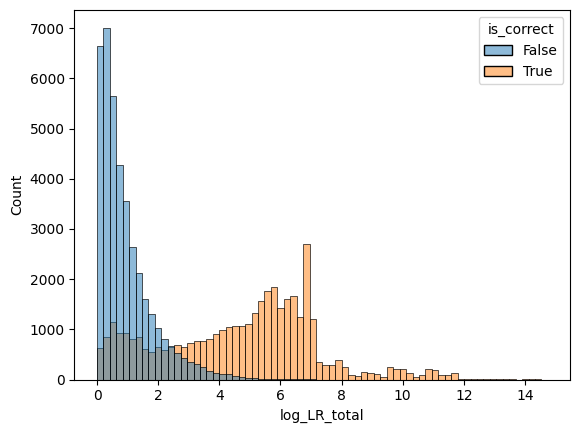

In [17]:
df_pos = df[df.is_correct].sample(40000)
df_neg = df[~df.is_correct].sample(40000)

sns.histplot(data=pd.concat([df_pos, df_neg]), x="log_LR_total", hue="is_correct")

In [12]:
df.sort_values("log_LR_total")

,structurePerIdRank,formulaRank,ConfidenceScoreExact,ConfidenceScoreApproximate,CSI:FingerIDScore,ZodiacScore,SiriusScoreNormalized,SiriusScore,molecularFormula,adduct,...,overallFeatureQuality,true_inchikey,is_correct,log_p_score_correct,log_p_score_incorrect,log_LR_score,log_p_confidence_correct,log_p_confidence_incorrect,log_LR_confidence,log_LR_total
385334,121,1,0.824,0.824,-1272.841,NaN,1.0,11.601,C17H17NO3,[M + Na]+,...,NaN,BRQQPHKRRCUYLA,False,-0.000011,-0.000022,0.000011,-0.964747,-0.955324,-0.009423,-0.009413
385333,120,1,0.824,0.824,-1160.327,NaN,1.0,11.601,C17H17NO3,[M + Na]+,...,NaN,BRQQPHKRRCUYLA,False,-0.000011,-0.000170,0.000159,-0.964747,-0.955324,-0.009423,-0.009265
385332,119,1,0.824,0.824,-1136.787,NaN,1.0,11.601,C17H17NO3,[M + Na]+,...,NaN,BRQQPHKRRCUYLA,False,-0.000011,-0.000239,0.000228,-0.964747,-0.955324,-0.009423,-0.009195
385331,118,1,0.824,0.824,-1133.759,NaN,1.0,11.601,C17H17NO3,[M + Na]+,...,NaN,BRQQPHKRRCUYLA,False,-0.000011,-0.000246,0.000235,-0.964747,-0.955324,-0.009423,-0.009189
385330,117,1,0.824,0.824,-1099.436,NaN,1.0,11.601,C17H17NO3,[M + Na]+,...,NaN,BRQQPHKRRCUYLA,False,-0.000034,-0.000412,0.000378,-0.964747,-0.955324,-0.009423,-0.009045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038706,1,1,0.999,0.999,-4.252,NaN,1.0,69.387,C15H21N3O2,[M + H]+,...,NaN,PIJVFDBKTWXHHD,True,-4.738499,-15.841039,11.102540,-6.503590,-9.788950,3.285360,14.387901
1039539,1,1,0.999,0.999,-4.252,NaN,1.0,69.394,C15H21N3O2,[M + H]+,...,NaN,PIJVFDBKTWXHHD,True,-4.738499,-15.841039,11.102540,-6.503590,-9.788950,3.285360,14.387901
2056909,1,1,0.999,0.999,-4.334,NaN,1.0,33.607,C15H21N3O2,[M + H]+,...,NaN,PIJVFDBKTWXHHD,True,-4.645180,-15.841039,11.195860,-6.503590,-9.788950,3.285360,14.481220
2056615,1,1,0.999,0.999,-4.368,NaN,1.0,53.984,C15H21N3O2,[M + H]+,...,NaN,PIJVFDBKTWXHHD,True,-4.626596,-15.841039,11.214443,-6.503590,-9.788950,3.285360,14.499803
